# **FAST SHAPELETS RESULTS**

#### **Preliminary steps**

In [1]:
### PACKAGES

import numpy as np
import matplotlib.pyplot as plt

In [2]:
### FUNCTIONS

from src.preprocessing import load_data, z_normalize_2d, add_noise

from src.fast_shapelets import compute_fast_shapelets_parallelized

from src.evaluation import (
    find_classification_criterion,
    predict,
    compute_accuracy,
    run_experiments,
    compute_randomness,
)

from src.visualization import (
    plot_shapelet,
    plot_series_with_shapelet,
    plot_results_experiments,
    plot_results_noise,
    plot_results_randomness,
)

In [3]:
### CONSTANTS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}

## **LOAD DATA**

In [4]:
### DATA

X_train, y_train = load_data("TRAIN")
X_test, y_test = load_data("TEST")

X_TRAIN shape (23, 136)
X_TEST shape (861, 136)


In [5]:
### Z-NORMALIZE

X_train = z_normalize_2d(X=X_train)
X_test = z_normalize_2d(X=X_test)

## **FIND SHAPELET**

In [6]:
shapelet_params = compute_fast_shapelets_parallelized(
    X_train=X_train, y_train=y_train, params=PARAMS
)
find_classification_criterion(
    X_train=X_train, y_train=y_train, shapelet_params=shapelet_params
)

## **EVALUATION**

### **Metrics**

In [7]:
### PREDICTIONS

y_pred_train = predict(X_test=X_train, shapelet_params=shapelet_params)
y_pred_test = predict(X_test=X_test, shapelet_params=shapelet_params)

In [8]:
### ACCURACY

accuracy_train = compute_accuracy(y_true=y_train, y_pred=y_pred_train)
accuracy_test = compute_accuracy(y_true=y_test, y_pred=y_pred_test)

print(f"Accuracy on train set: {100*accuracy_train:.2f} %")
print(f"Accuracy on test set: {100*accuracy_test:.2f} %")

Accuracy on train set: 95.65 %
Accuracy on test set: 92.45 %


### **Plots**

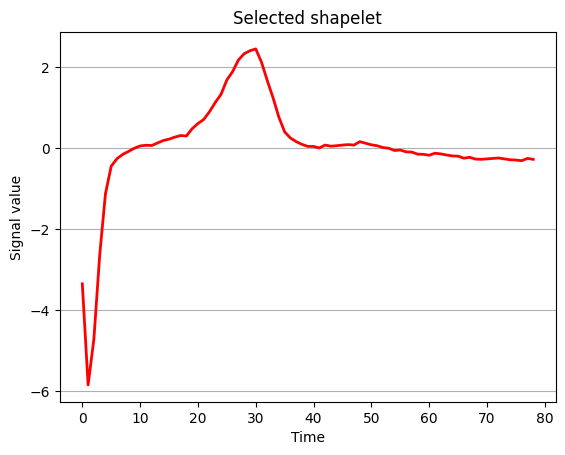

In [9]:
### SELECTED SHAPELET

plot_shapelet(shapelet_params=shapelet_params)

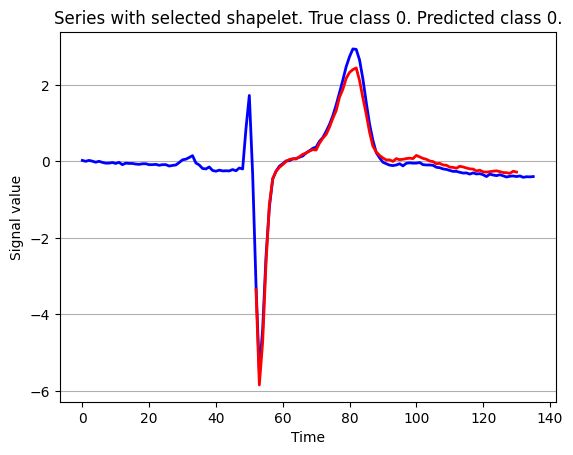

In [10]:
### PLOT SHAPELET ON A SERIES

SERIES_IDX = 101

plot_series_with_shapelet(
    X=X_test, y=y_test, shapelet_params=shapelet_params, index=SERIES_IDX
)

## **RANDOMNESS**

In [3]:
### DATA

X_train, y_train = load_data("TRAIN")
X_test, y_test = load_data("TEST")

X_train = z_normalize_2d(X=X_train)
X_test = z_normalize_2d(X=X_test)


X_TRAIN shape (23, 136)
X_TEST shape (861, 136)


In [4]:
### COMPUTE RANDOMNESS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
iterations, train_accuracies, test_accuracies = compute_randomness(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    nb_times=20,
)


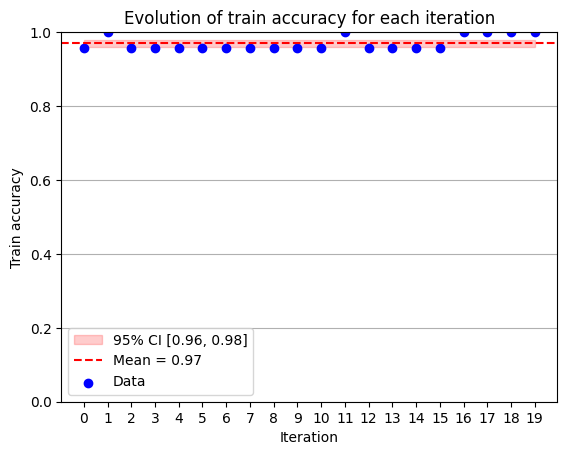

In [5]:
### PLOT : TRAIN ACCURACY

plot_results_randomness(
    iterations=iterations,
    train_accuracies=train_accuracies,
    test_accuracies=test_accuracies,
    objective="train",
)


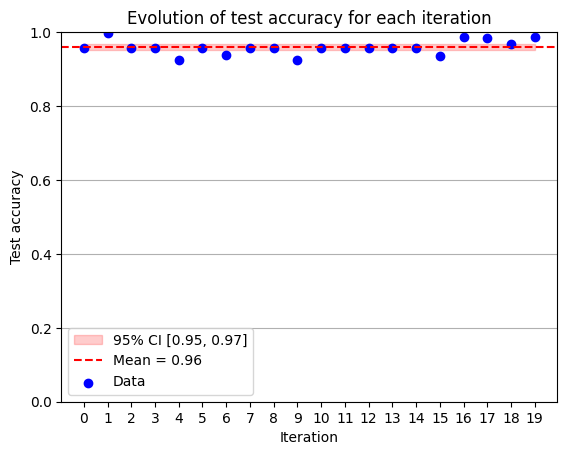

In [6]:
### PLOT : TEST ACCURACY

plot_results_randomness(
    iterations=iterations,
    train_accuracies=train_accuracies,
    test_accuracies=test_accuracies,
    objective="test",
)


In [7]:
test_accuracies

array([0.95818815, 0.99767712, 0.95818815, 0.95818815, 0.92450639,
       0.95818815, 0.93844367, 0.95818815, 0.95818815, 0.92450639,
       0.95818815, 0.95586527, 0.95818815, 0.95818815, 0.95818815,
       0.93495935, 0.98722416, 0.98373984, 0.96864111, 0.98722416])

## **EXPERIMENTS**

### **Dimensionality**

In [6]:
### RUN EXPERIMENTS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
PARAM_TO_TEST = "dimensionality"
VALUES = np.arange(start=1, stop=21, step=1)
values, accuracies, times = run_experiments(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    param_to_test=PARAM_TO_TEST,
    values=VALUES,
)

100%|██████████| 20/20 [38:23<00:00, 115.20s/it]


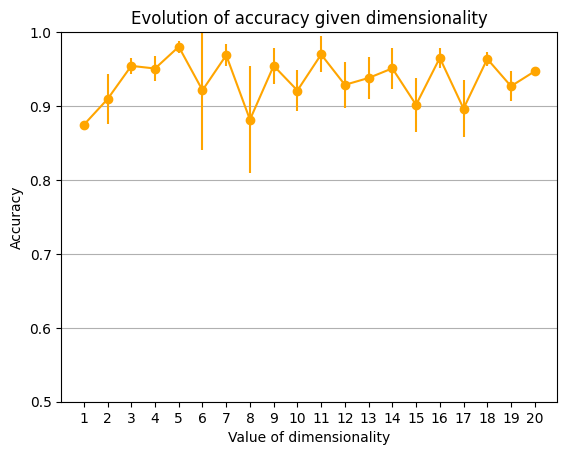

In [8]:
### PLOT : ACCURACY

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="accuracy",
)

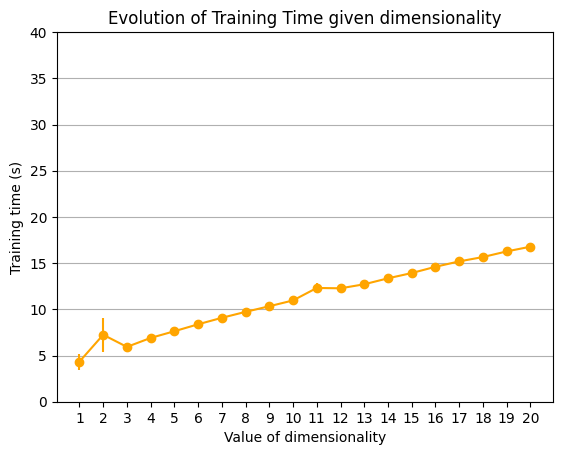

In [9]:
### PLOT : TRAINING TIME

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="Training Time",
)


### **Cardinality**

In [10]:
### RUN EXPERIMENTS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
PARAM_TO_TEST = "cardinality"
VALUES = np.arange(start=1, stop=21, step=1)
values, accuracies, times = run_experiments(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    param_to_test=PARAM_TO_TEST,
    values=VALUES,
)


100%|██████████| 20/20 [49:46<00:00, 149.33s/it]


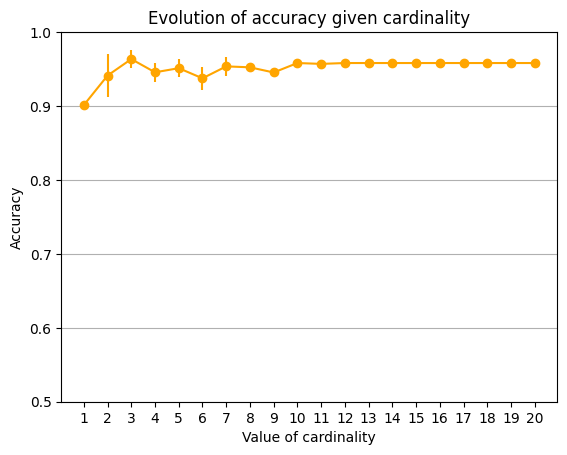

In [12]:
### PLOT : ACCURACY

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="accuracy",
)


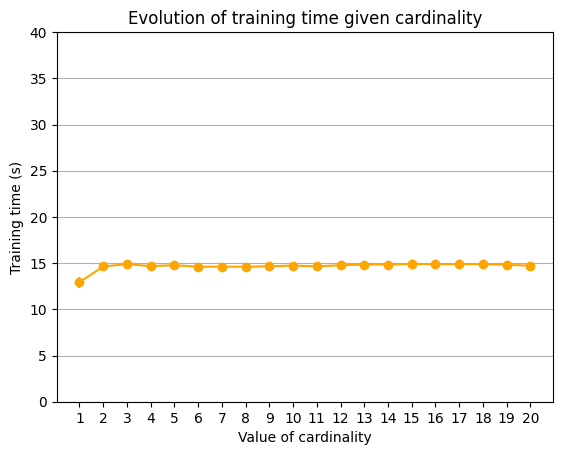

In [13]:
### PLOT : TRAINING TIME

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="training time",
)


### **R**

In [19]:
### RUN EXPERIMENTS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
PARAM_TO_TEST = "r"
VALUES = np.arange(start=2, stop=22, step=2)
values, accuracies, times = run_experiments(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    param_to_test=PARAM_TO_TEST,
    values=VALUES,
)


100%|██████████| 10/10 [02:22<00:00, 14.23s/it]


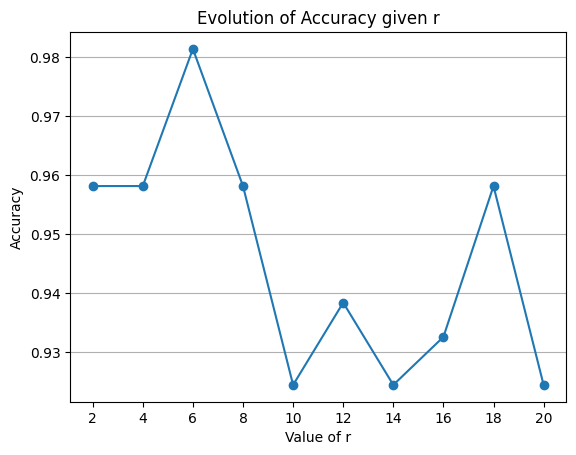

In [ ]:
### PLOT : ACCURACY

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="accuracy",
)


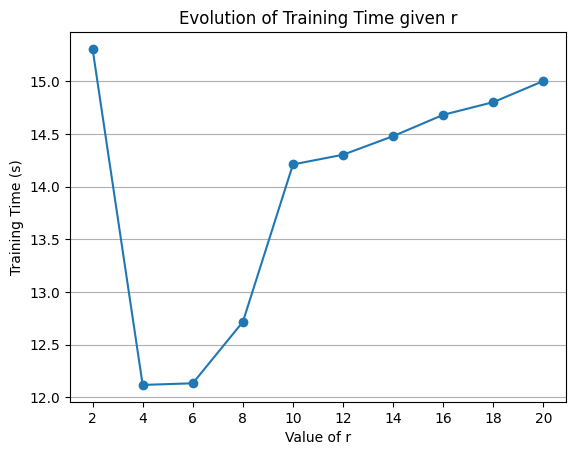

In [ ]:
### PLOT : TRAINING TIME

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="training time",
)


### **K**

In [20]:
### RUN EXPERIMENTS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
PARAM_TO_TEST = "k"
VALUES = np.arange(start=1, stop=21, step=1)
values, accuracies, times = run_experiments(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    param_to_test=PARAM_TO_TEST,
    values=VALUES,
)


100%|██████████| 2/2 [00:28<00:00, 14.32s/it]


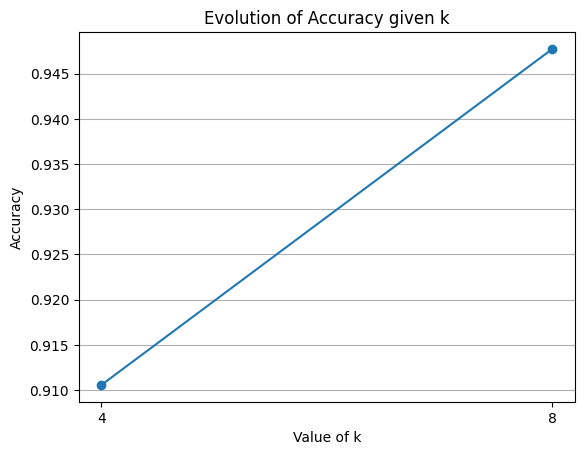

In [21]:
### PLOT : ACCURACY

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="accuracy",
)


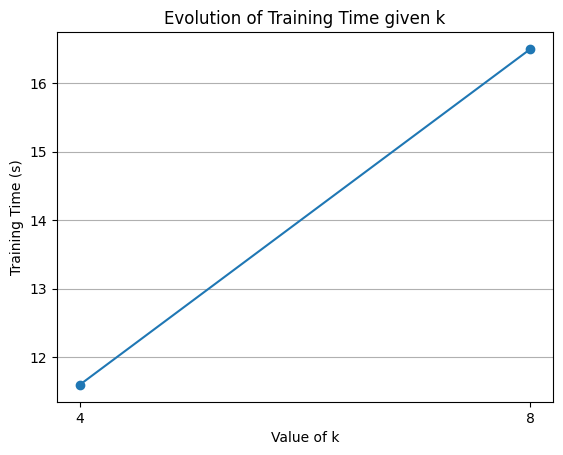

In [22]:
### PLOT : TRAINING TIME

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="training time",
)


### **Proba**

In [23]:
### RUN EXPERIMENTS

PARAMS = {"dimensionality": 16, "cardinality": 4, "r": 10, "k": 10, "proba": 0.8}
PARAM_TO_TEST = "proba"
VALUES = np.linspace(start=0.1, stop=0.9, num=2)
values, accuracies, times = run_experiments(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=PARAMS,
    param_to_test=PARAM_TO_TEST,
    values=VALUES,
)


100%|██████████| 2/2 [00:35<00:00, 17.63s/it]


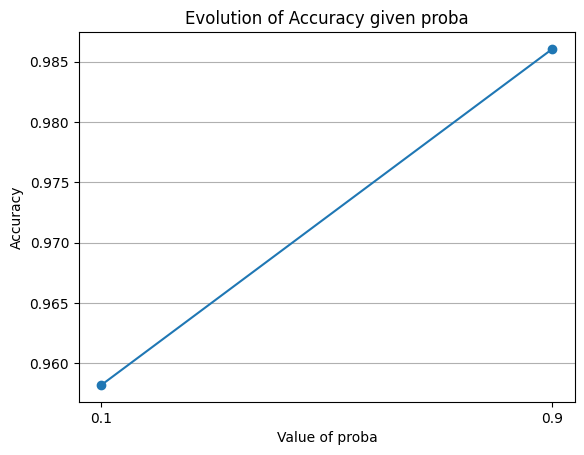

In [24]:
### PLOT : ACCURACY

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="accuracy",
)


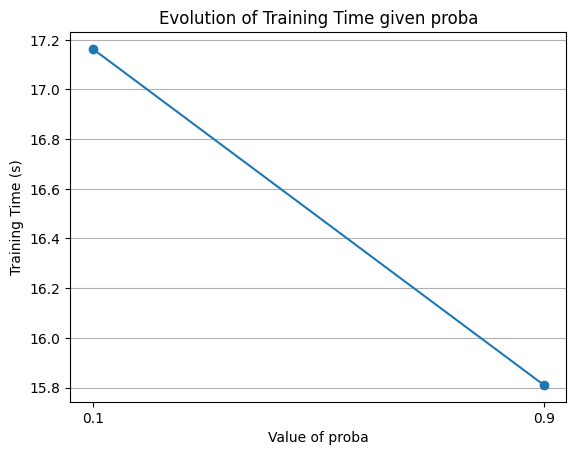

In [25]:
### PLOT : TRAINING TIME

plot_results_experiments(
    values=values,
    accuracies=accuracies,
    times=times,
    param_to_test=PARAM_TO_TEST,
    objective="training time",
)


## **NOISE IN DATA**

In [10]:
SIGMAS = [0, 2]
X_train, y_train = load_data("TRAIN")
X_test, y_test = load_data("TEST")

X_train_norm = z_normalize_2d(X=X_train)
X_test_norm = z_normalize_2d(X=X_test)


X_TRAIN shape (23, 136)
X_TEST shape (861, 136)


### **Noise in training data**

In [7]:
### COMPUTE ACCURACIES

list_accuracies = []
for sigma in SIGMAS:
    X_train_noised = add_noise(X=X_train, sigma=sigma)
    X_train_noised = z_normalize_2d(X=X_train_noised)
    shapelet_params = compute_fast_shapelets_parallelized(
        X_train=X_train_noised, y_train=y_train, params=PARAMS
    )
    find_classification_criterion(
        X_train=X_train_noised, y_train=y_train, shapelet_params=shapelet_params
    )
    y_pred_train = predict(X_test=X_train_noised, shapelet_params=shapelet_params)
    y_pred_test = predict(X_test=X_test_norm, shapelet_params=shapelet_params)
    accuracy_train = compute_accuracy(y_true=y_train, y_pred=y_pred_train)
    accuracy_test = compute_accuracy(y_true=y_test, y_pred=y_pred_test)
    list_accuracies.append((accuracy_train, accuracy_test))
train_accuracies = [x[0] for x in list_accuracies]
test_accuracies = [x[1] for x in list_accuracies]


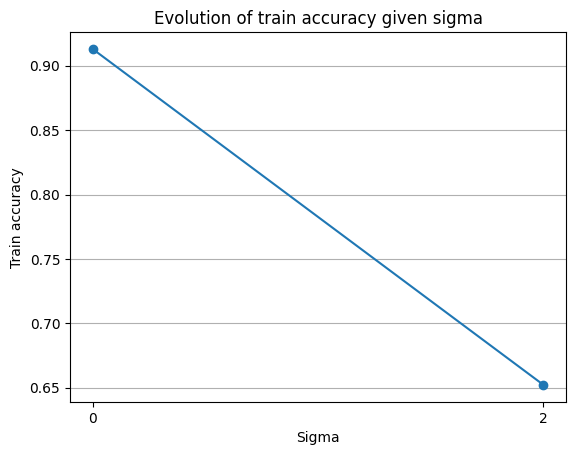

In [8]:
### PLOT : TRAIN ACCURACY

plot_results_noise(
    sigmas=SIGMAS,
    train_accuracies=train_accuracies,
    test_accuracies=test_accuracies,
    objective="train",
)


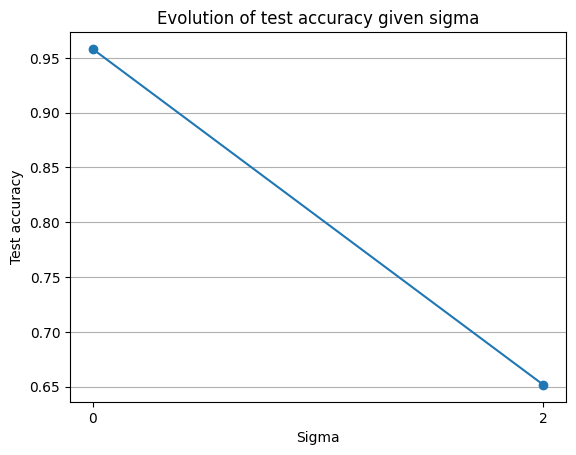

In [9]:
### PLOT : TEST ACCURACY

plot_results_noise(
    sigmas=SIGMAS,
    train_accuracies=train_accuracies,
    test_accuracies=test_accuracies,
    objective="test",
)


### **Noise in test data**

In [11]:
### COMPUTE ACCURACIES

shapelet_params = compute_fast_shapelets_parallelized(
    X_train=X_train_norm, y_train=y_train, params=PARAMS
)
find_classification_criterion(
    X_train=X_train_norm, y_train=y_train, shapelet_params=shapelet_params
)
test_accuracies = []
for sigma in SIGMAS:
    X_test_noised = add_noise(X=X_test, sigma=sigma)
    X_test_noised = z_normalize_2d(X=X_test_noised)
    y_pred_test = predict(X_test=X_test_noised, shapelet_params=shapelet_params)
    accuracy_test = compute_accuracy(y_true=y_test, y_pred=y_pred_test)
    test_accuracies.append(accuracy_test)


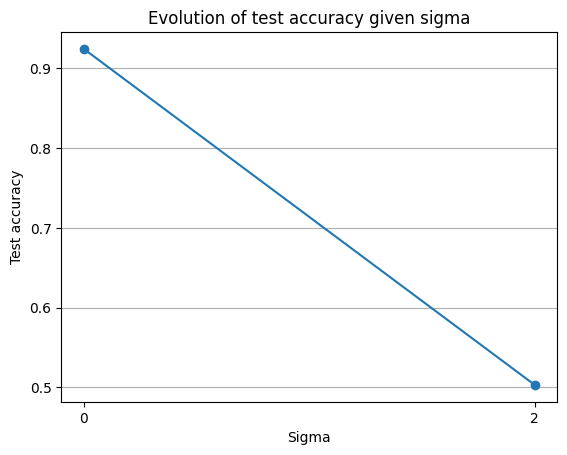

In [12]:
### PLOT : TEST ACCURACY

plot_results_noise(
    sigmas=SIGMAS,
    train_accuracies=None,
    test_accuracies=test_accuracies,
    objective="test",
)


### **Noise in both train and test data**

In [13]:
### COMPUTE ACCURACIES

list_accuracies = []
for sigma in SIGMAS:
    X_train_noised = add_noise(X=X_train, sigma=sigma)
    X_test_noised = add_noise(X=X_test, sigma=sigma)
    X_train_noised = z_normalize_2d(X=X_train_noised)
    X_test_noised = z_normalize_2d(X=X_test_noised)
    shapelet_params = compute_fast_shapelets_parallelized(
        X_train=X_train_noised, y_train=y_train, params=PARAMS
    )
    find_classification_criterion(
        X_train=X_train_noised, y_train=y_train, shapelet_params=shapelet_params
    )
    y_pred_train = predict(X_test=X_train_noised, shapelet_params=shapelet_params)
    y_pred_test = predict(X_test=X_test_noised, shapelet_params=shapelet_params)
    accuracy_train = compute_accuracy(y_true=y_train, y_pred=y_pred_train)
    accuracy_test = compute_accuracy(y_true=y_test, y_pred=y_pred_test)
    list_accuracies.append((accuracy_train, accuracy_test))
train_accuracies = [x[0] for x in list_accuracies]
test_accuracies = [x[1] for x in list_accuracies]


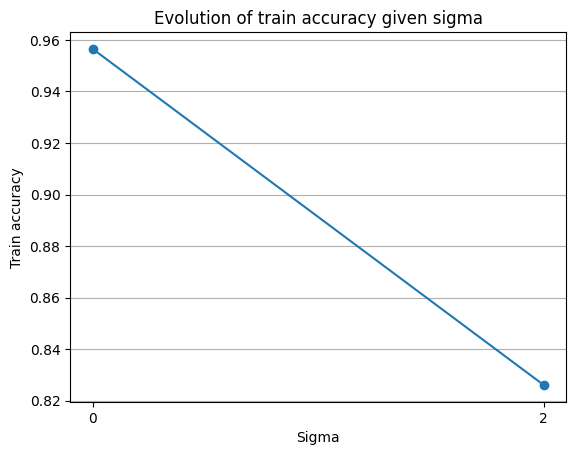

In [14]:
### PLOT : TRAIN ACCURACY

plot_results_noise(
    sigmas=SIGMAS,
    train_accuracies=train_accuracies,
    test_accuracies=test_accuracies,
    objective="train",
)


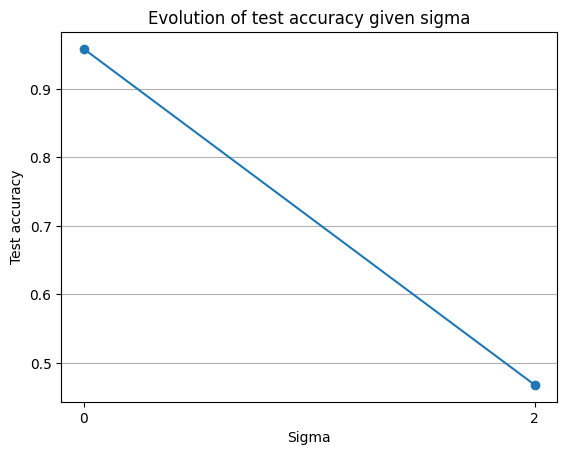

In [15]:
### PLOT : TEST ACCURACY

plot_results_noise(
    sigmas=SIGMAS,
    train_accuracies=train_accuracies,
    test_accuracies=test_accuracies,
    objective="test",
)
